## Exploration of rude audios
Este notebook se encarga de manera breve y directa de escanear los audios originales, filtrarlos (asegurando qué vocales y repeticiones usamos) y generar un CSV con los metadatos y duraciones de cada audio. 

**Nota**: La copia física a la carpeta `audios_ordenados` se hace ahora a través del script `organizar_audios.py` para mantener este notebook rápido y limpio.

In [12]:
import os
import re
import pandas as pd
import soundfile as sf
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

######### RUTAS #########
BASE_DIR = Path(os.getcwd()).parent.parent
DATA_DIR = BASE_DIR / 'data'
NEUROVOZ_AUDIO_DIR = DATA_DIR / 'crudo' / 'neurovoz' / 'audios'
PCGITA_DIR         = DATA_DIR / 'crudo' / 'pc-gita'

PROCESSED_DIR = DATA_DIR / 'processed'
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

# Configuración
VOCALES_INTERES = ['A', 'E']
REPETICIONES_NV = [1, 2, 3]

In [13]:
#### 1. RECOPILACIÓN Y LIMPIEZA NEUROVOZ
VOCAL_PATTERN_NV = re.compile(r'^(HC|PD)_([AEIOUaeiou])(\d+)_(\d+)$')

def parse_neurovoz_filename(filepath):
    m = VOCAL_PATTERN_NV.match(filepath.stem)
    if m:
        return {
            'filepath':   str(filepath),
            'dataset':    'neurovoz',
            'label':      m.group(1),
            'vocal':      m.group(2).upper(),
            'repeticion': int(m.group(3)),
            'patient_id': m.group(4),
        }
    return None

all_nv_files = sorted(NEUROVOZ_AUDIO_DIR.glob('*.wav'))
records = []
for wav in all_nv_files:
    info = parse_neurovoz_filename(wav)
    if info is None or info['vocal'] not in VOCALES_INTERES or info['repeticion'] not in REPETICIONES_NV:
        continue
    records.append(info)

df_nv = pd.DataFrame(records)
print(f"Total audios Neurovoz seleccionados: {len(df_nv)}")

Total audios Neurovoz seleccionados: 454


In [14]:
#### 2. RECOPILACIÓN Y LIMPIEZA PC-GITA
records_pg = []
for grupo in ['Control', 'Patologicas']:
    grupo_dir = PCGITA_DIR / grupo
    if not grupo_dir.exists(): continue
    label = 'HC' if grupo == 'Control' else 'PD'
    for vocal_dir in grupo_dir.iterdir():
        if not vocal_dir.is_dir(): continue
        vocal = vocal_dir.name.upper()
        if vocal not in VOCALES_INTERES: continue
        for wav in sorted(vocal_dir.glob('*.wav')):
            match_id = re.search(r'\d{4}', wav.stem)
            num_paciente = match_id.group() if match_id else '0000'
            paciente_id = f"{label}_{num_paciente}"
            match_rep = re.search(r'(\d+)$', wav.stem)
            repeticion = int(match_rep.group(1)) if match_rep else 1
            records_pg.append({
                'filepath': str(wav),
                'dataset': 'pc-gita',
                'label': label,
                'vocal': vocal,
                'repeticion': repeticion,
                'patient_id': paciente_id
            })

df_pg = pd.DataFrame(records_pg)
print(f"Total audios PC-GITA seleccionados: {len(df_pg)}")

Total audios PC-GITA seleccionados: 600


In [15]:
#### RESUMEN ESTADÍSTICO DE LOS DATASETS ####

print("=" * 65)
print("NEUROVOZ — Resumen por vocal y grupo")
print("=" * 65)

for vocal in VOCALES_INTERES:
    print(f"\n  Vocal {vocal}:")
    for label in ["HC", "PD"]:
        sub = df_nv[(df_nv['vocal'] == vocal) & (df_nv['label'] == label)]
        if sub.empty:
            continue
        n_audios = len(sub)
        n_pacientes = sub['patient_id'].nunique()

        # Distribución de repeticiones
        reps = sub.groupby('patient_id')['repeticion'].apply(set)
        solo_1 = (reps.apply(lambda r: r == {1})).sum()
        solo_2 = (reps.apply(lambda r: r == {2})).sum()
        ambas  = (reps.apply(lambda r: {1,2}.issubset(r))).sum()

        print(f"    [{label}] {n_pacientes} pacientes | {n_audios} audios "
              f"→ solo rep1: {solo_1}, solo rep2: {solo_2}, rep1+rep2: {ambas}")

print(f"\n\nNeurovoz TOTAL: {len(df_nv)} audios | "
      f"{df_nv['patient_id'].nunique()} pacientes únicos "
      f"({df_nv[df_nv['label']=='HC']['patient_id'].nunique()} HC, "
      f"{df_nv[df_nv['label']=='PD']['patient_id'].nunique()} PD)")

print("=" * 65)
print("PC-GITA — Resumen por vocal y grupo")
print("=" * 65)

for vocal in VOCALES_INTERES:
    print(f"\n  Vocal {vocal}:")
    for label in ["HC", "PD"]:
        sub = df_pg[(df_pg['vocal'] == vocal) & (df_pg['label'] == label)]
        if sub.empty:
            continue
        n_audios = len(sub)
        n_pacientes = sub['patient_id'].nunique()

        reps = sub.groupby('patient_id')['repeticion'].apply(set)
        solo_1 = (reps.apply(lambda r: r == {1})).sum()
        solo_2 = (reps.apply(lambda r: r == {2})).sum()
        solo_3 = (reps.apply(lambda r: r == {3})).sum()
        tres   = (reps.apply(lambda r: {1,2,3}.issubset(r))).sum()

        print(f"    [{label}] {n_pacientes} pacientes | {n_audios} audios "
              f"→ solo rep1: {solo_1}, solo rep2: {solo_2}, solo rep3: {solo_3}, "
              f"rep1+2+3: {tres}")

print(f"\n\nPC-GITA TOTAL: {len(df_pg)} audios | "
      f"{df_pg['patient_id'].nunique()} pacientes únicos "
      f"({df_pg[df_pg['label']=='HC']['patient_id'].nunique()} HC, "
      f"{df_pg[df_pg['label']=='PD']['patient_id'].nunique()} PD)")


NEUROVOZ — Resumen por vocal y grupo

  Vocal A:
    [HC] 58 pacientes | 116 audios → solo rep1: 3, solo rep2: 0, rep1+rep2: 55
    [PD] 53 pacientes | 134 audios → solo rep1: 1, solo rep2: 0, rep1+rep2: 52

  Vocal E:
    [HC] 58 pacientes | 83 audios → solo rep1: 2, solo rep2: 32, rep1+rep2: 23
    [PD] 53 pacientes | 121 audios → solo rep1: 1, solo rep2: 0, rep1+rep2: 44


Neurovoz TOTAL: 454 audios | 111 pacientes únicos (58 HC, 53 PD)
PC-GITA — Resumen por vocal y grupo

  Vocal A:
    [HC] 50 pacientes | 150 audios → solo rep1: 0, solo rep2: 0, solo rep3: 0, rep1+2+3: 50
    [PD] 50 pacientes | 150 audios → solo rep1: 0, solo rep2: 0, solo rep3: 0, rep1+2+3: 50

  Vocal E:
    [HC] 50 pacientes | 150 audios → solo rep1: 0, solo rep2: 0, solo rep3: 0, rep1+2+3: 50
    [PD] 50 pacientes | 150 audios → solo rep1: 0, solo rep2: 0, solo rep3: 0, rep1+2+3: 50


PC-GITA TOTAL: 600 audios | 100 pacientes únicos (50 HC, 50 PD)


In [16]:
#### 3. CÁLCULO DE DURACIONES Y EXPORTACIÓN DE METADATOS
def get_duration(filepath):
    try:
        info = sf.info(filepath)
        return info.frames / info.samplerate
    except:
        return None

df_nv['duration_s'] = df_nv['filepath'].apply(get_duration)
df_pg['duration_s'] = df_pg['filepath'].apply(get_duration)

# Limpiar posibles errores
df_nv = df_nv.dropna(subset=['duration_s']).reset_index(drop=True)
df_pg = df_pg.dropna(subset=['duration_s']).reset_index(drop=True)

df_nv.to_csv(PROCESSED_DIR / 'metadata_neurovoz.csv', index=False)
df_pg.to_csv(PROCESSED_DIR / 'metadata_pcgita.csv', index=False)

print(f"Archivos de metadatos generados con éxito en la carpeta 'processed'.")
print("Ahora debes ejecutar el script en tu terminal o IDE: python organizar_audios.py")

Archivos de metadatos generados con éxito en la carpeta 'processed'.
Ahora debes ejecutar el script en tu terminal o IDE: python organizar_audios.py


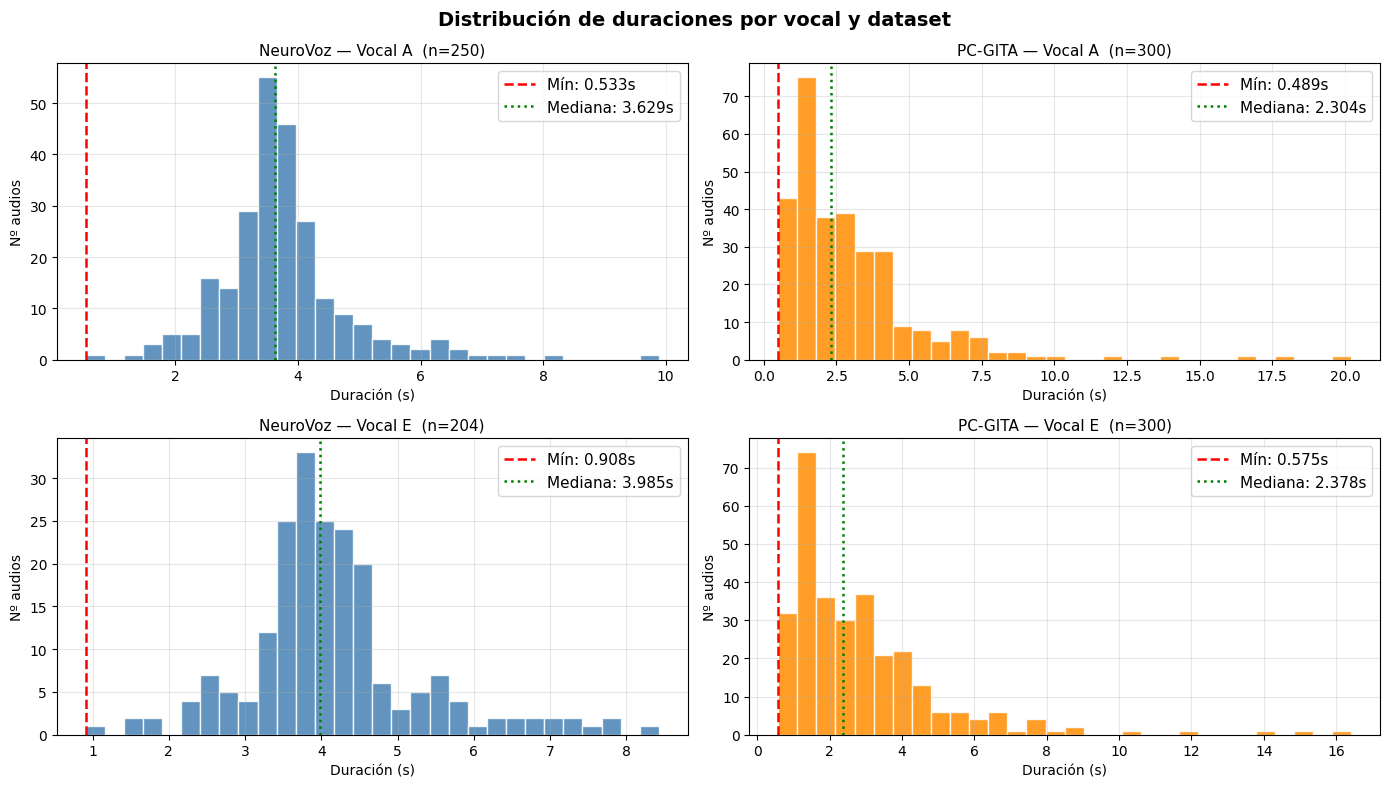

In [17]:
#### DISTRIBUCIÓN DE DURACIONES — Histogramas con línea de mínimo ####
import matplotlib.pyplot as plt

fig, axes = plt.subplots(len(VOCALES_INTERES), 2, figsize=(14, 4 * len(VOCALES_INTERES)))
fig.suptitle("Distribución de duraciones por vocal y dataset", fontsize=14, fontweight='bold')

datasets = [
    (df_nv, "NeuroVoz",  "steelblue"),
    (df_pg, "PC-GITA",   "darkorange"),
]

for col, (df, ds_name, color) in enumerate(datasets):
    for row, vocal in enumerate(VOCALES_INTERES):
        ax = axes[row][col]
        data = df[df['vocal'] == vocal]['duration_s']

        ax.hist(data, bins=30, color=color, edgecolor='white', alpha=0.85)

        # Línea del mínimo (posible umbral de recorte)
        dur_min = data.min()
        ax.axvline(dur_min, color='red', linestyle='--', lw=1.8,
                   label=f'Mín: {dur_min:.3f}s')

        # Línea de la mediana (referencia de "audio típico")
        dur_med = data.median()
        ax.axvline(dur_med, color='green', linestyle=':', lw=1.8,
                   label=f'Mediana: {dur_med:.3f}s')

        ax.set_title(f'{ds_name} — Vocal {vocal}  (n={len(data)})', fontsize=11)
        ax.set_xlabel('Duración (s)')
        ax.set_ylabel('Nº audios')
        ax.legend(fontsize=11)
        ax.grid(alpha=0.3)

plt.tight_layout()
plt.show()
